In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import geopandas as gp
import pickle
import arviz as az
import os
import sys
import re
import matplotlib.colors as mcolors

from matplotlib.transforms import ScaledTranslation

from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

In [3]:
cd ../

In [4]:
sys.path.insert(0, './src/')

In [5]:
from plot.odds_ratios import *

In [7]:
alpha_violin_plot_soc = 0.7
alpha_soc_backgound = 0.45

In [8]:
idata = az.from_netcdf('./idata/uk/rsv_intent_causal_w_soc.nc')

with open('./dat/dat_for_inference/uk/var_mappings_rsv_causal_w_soc.p', 'rb') as f:
    var_mappings = pickle.load(f)
with open('./dat/dat_for_inference/uk/data_dict_rsv_causal_w_soc.p', 'rb') as f:
    data_dict = pickle.load(f)
survey = pd.read_csv('./dat/dat_for_inference/uk/survey_rsv_causal_w_soc.tsv', sep = '\t', index_col = 0)
micro = pd.read_csv('./dat/dat_for_inference/uk/micro_rsv_causal_w_soc.tsv', sep = '\t', index_col = 0)

itl3_to_country = dict( zip(micro['itl3'], micro['country'] )  )

survey['country'] = survey['itl3'].map(itl3_to_country)

num_samples = idata.posterior.chain.size * idata.posterior.draw.size

In [9]:
lad21_to_itl21 = pd.read_csv('./dat/region_mappings/Local_Authority_District_(April_2021)_to_LAU1_to_ITL3_to_ITL2_to_ITL1_(January_2021)_Lookup_in_United_Kingdom.csv')
itl321_cd_to_nm = dict( zip (lad21_to_itl21['ITL321CD'], lad21_to_itl21['ITL321NM']) )

In [10]:
recode_mapping_reverse = var_mappings['recode_mapping_reverse']

rename_mapping_for_plot = {}

recode_mapping_for_plot = recode_mapping_reverse.copy()

value_mapping = {}

value_mapping['DIS'] = {
    'Not disabled under the Equality Act': 'Not disabled',
    
    'Disabled under the Equality Act: Day-to-day activities limited a little': 'Disabled:\nlimited a little',
    
    'Disabled under the Equality Act: Day-to-day activities limited a lot': 'Disabled:\nlimited a lot'
}

value_mapping['EMP'] = {
    'Economically inactive: Student': 'Student, inactive',
    'Economically Active Full-time students': 'Student, active',
    'Economically inactive: Long-term sick or disabled': 'Long-term sick',
    'Economically inactive: Other': 'Inactive other',
    'Economically inactive: Looking after home or family': 'Looking after home',
    'Working part or full-time (including self-employed, excluding students)': 'Working',
    'Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks': 'Seeking work',
    'Economically inactive: Retired': 'Retired'
}

value_mapping['LAN'] = {'English (English or Welsh in Wales)' : 'English', 'Other' : 'Other', 'Polish' : 'Polish'}

for _var, _mapping in value_mapping.items():
    new_dict = recode_mapping_for_plot[_var].copy()
    new_dict = { k : _mapping[v] for k,v in new_dict.items() }
    recode_mapping_for_plot[_var] = new_dict.copy()

for k in recode_mapping_for_plot:
    rename_mapping_for_plot[k] = { v : recode_mapping_for_plot[k][i] for i,v in recode_mapping_reverse[k].items()}

rename_mapping_for_plot['itl3'] = itl321_cd_to_nm

rename_mapping_for_plot['itl3']['TLM61_64_65_66'] = 'TLM61-64-65-66'

rename_mapping_for_plot['country'] = {'ew' :'England Wales', 'ni' : 'Northern Ireland', 'scot' : 'Scotland'}

rename_mapping_for_plot['no_post_strat_var'] = {'Marginal' : 'Marginal'}

for k,d in rename_mapping_for_plot.items():
    if k in survey.columns:
        survey[k] = survey[k].map(d)

soc_dems = ['AGE', 'SEX', 'EDU', 'REL', 'ETH', 'LAN', 'MIG', 'BUK', 'YUK', 'HEA', 'SCH', 'DIS', 'ENP', 'EMP']

In [11]:
def _post_idx(s):
    pattern = r'p(\d+)pre_p(\d+)post_(\d+)'
    match = re.search(pattern, s)
    j = int(match.group(2))
    k = int(match.group(3))
    return f'p{j}_{k}'

df_post_strat_dict = {}
post_strat_path = './post_strat/uk/rsv_causal_varying_c' # './post_strat/uk/rsv_causal'
_var_list =  ['no_post_strat_var', 'AGE', 'SEX', 'EDU','REL', 'ETH', 'LAN', 'MIG', 'BUK', 'DIS', 'HEA', 'EMP', 'country'] #  'itl3'
for var_post_strat in _var_list:
    df_post_strat_dict[var_post_strat] = {}
    for var_name in ['p1','p2','p3','p4']:
        df_post_strat_dict[var_post_strat][var_name] = {}
        for treat in range(7):
            df_post_strat_dict[var_post_strat][var_name][treat] = {}
            _df = pd.read_csv( os.path.join(post_strat_path, f'{var_post_strat}_rsv_pre_{var_name}_post{treat}_p1p2p3p4.tsv'), sep = '\t', index_col = 0 )
            if var_post_strat == 'no_post_strat_var':
                _df = pd.DataFrame(_df).T
                _df.index = ['Marginal']
            old_columns = _df.columns
            new_columns = [_post_idx(c) for c in old_columns] # [ f'{var_name}_{c}' for c in old_columns] # if c != var_post_strat]
            _df.columns = new_columns
            df_post_strat_dict[var_post_strat][var_name][treat] = _df.copy()


In [12]:
df_post_strat_dict['no_post_strat_var']['p1'].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6])

In [13]:
def get_net_changes(df_post_strat_dict, var_post_strat, rename_mapping_for_plot, N_dep = 4, N_treat = 7, num_samples = 2000):

    categories = list( rename_mapping_for_plot[var_post_strat].values())
    categories = list( np.sort(categories) )

    rename_mapping_for_plot_rev = {}
    for k1,v1 in rename_mapping_for_plot.items():
        rename_mapping_for_plot_rev[k1] = {v:k for k,v in v1.items()}
    
    num_cats = len(categories)
    
    df_increase_dict = { t : pd.DataFrame( index = [f's_{i}' for i in range(num_samples)], columns = categories) for t in range(N_treat) }
    df_decrease_dict = { t : pd.DataFrame( index = [f's_{i}' for i in range(num_samples)], columns = categories) for t in range(N_treat) }
    df_net_change_dict = { t : pd.DataFrame( index = [f's_{i}' for i in range(num_samples)], columns = categories) for t in range(N_treat) }
    
    for n,cat in enumerate(categories):
        original_cat = rename_mapping_for_plot_rev[var_post_strat][cat]
        prob_joint_pre_post = np.zeros((num_samples, N_dep, N_treat, N_dep))
        
        prob_pre_post_cond_on_pre = np.zeros((num_samples, N_dep, N_treat, N_dep))
        
        prob_pre = np.zeros((num_samples, N_dep, N_treat))
        
        for p1 in range(N_dep):
            for t in range(N_treat):
                _df = df_post_strat_dict[var_post_strat][f'p{p1+1}'][t].copy()
                _prob_pre = np.zeros((num_samples,))
                for p2 in range(N_dep):
                    cols = [f'p{p2+1}_{s}' for s in range(num_samples)]
                    vals = _df[cols].loc[original_cat].values
                    prob_joint_pre_post[:, p1, t, p2] = vals 
                    _prob_pre += vals
                prob_pre[:,p1,t] = _prob_pre
        
        for p1 in range(N_dep):
            for t in range(N_treat):
                for p2 in range(N_dep):
                    prob_pre_post_cond_on_pre[:, p1, t, p2] = prob_joint_pre_post[:, p1, t, p2] / prob_pre[:,p1,t]

        ##############

        prob_pre_post_cond_on_pre_increase = np.zeros((num_samples, N_dep, N_treat))
        prob_pre_post_cond_on_pre_decrease = np.zeros((num_samples, N_dep, N_treat))
        
        for i in range(N_dep):
            prob_pre_post_cond_on_pre_increase[:, i, :] = np.sum(prob_pre_post_cond_on_pre[:, i, :, i+1:], axis=-1)
        
            prob_pre_post_cond_on_pre_decrease[:, i, :] = np.sum(prob_pre_post_cond_on_pre[:, i, :, :i], axis=-1)
        
        prob_post_increase = np.zeros( (num_samples, N_treat) )
        prob_post_decrease = np.zeros( (num_samples, N_treat) )
        
        for i in range(N_dep):
            prob_post_increase += prob_pre_post_cond_on_pre_increase[:, i, :] * prob_pre[:, i, :]
            prob_post_decrease += prob_pre_post_cond_on_pre_decrease[:, i, :] * prob_pre[:, i, :]
        
        prob_post_net_change = prob_post_increase - prob_post_decrease

        for t in range(N_treat):
            df_increase_dict[t][cat] = prob_post_increase[:,t]
            df_decrease_dict[t][cat] = prob_post_decrease[:,t]
            df_net_change_dict[t][cat] = prob_post_net_change[:,t]

    return {'increase' : df_increase_dict, 'decrease' : df_decrease_dict, 'net_change' : df_net_change_dict}

_var_list =  ['no_post_strat_var', 'AGE', 'SEX', 'EDU','REL', 'ETH', 'LAN', 'MIG', 'BUK', 'DIS', 'HEA', 'EMP', 'country'] # 'itl3'
change_dict = {}
for var in _var_list:
    change_dict[var] = get_net_changes(df_post_strat_dict, var_post_strat = var, rename_mapping_for_plot = rename_mapping_for_plot, N_dep = 4, N_treat = 7, num_samples = num_samples)

In [14]:
change_dict['SEX']['net_change'][6] - change_dict['SEX']['net_change'][3]

,Female,Male
s_0,0.037412,-0.003632
s_1,0.040275,0.005083
s_2,0.072350,0.095531
s_3,0.026880,-0.028765
s_4,0.044403,-0.030388
...,...,...
s_1995,0.007456,-0.026668
s_1996,0.064397,0.064008
s_1997,0.080038,0.013386
s_1998,-0.001087,0.024797


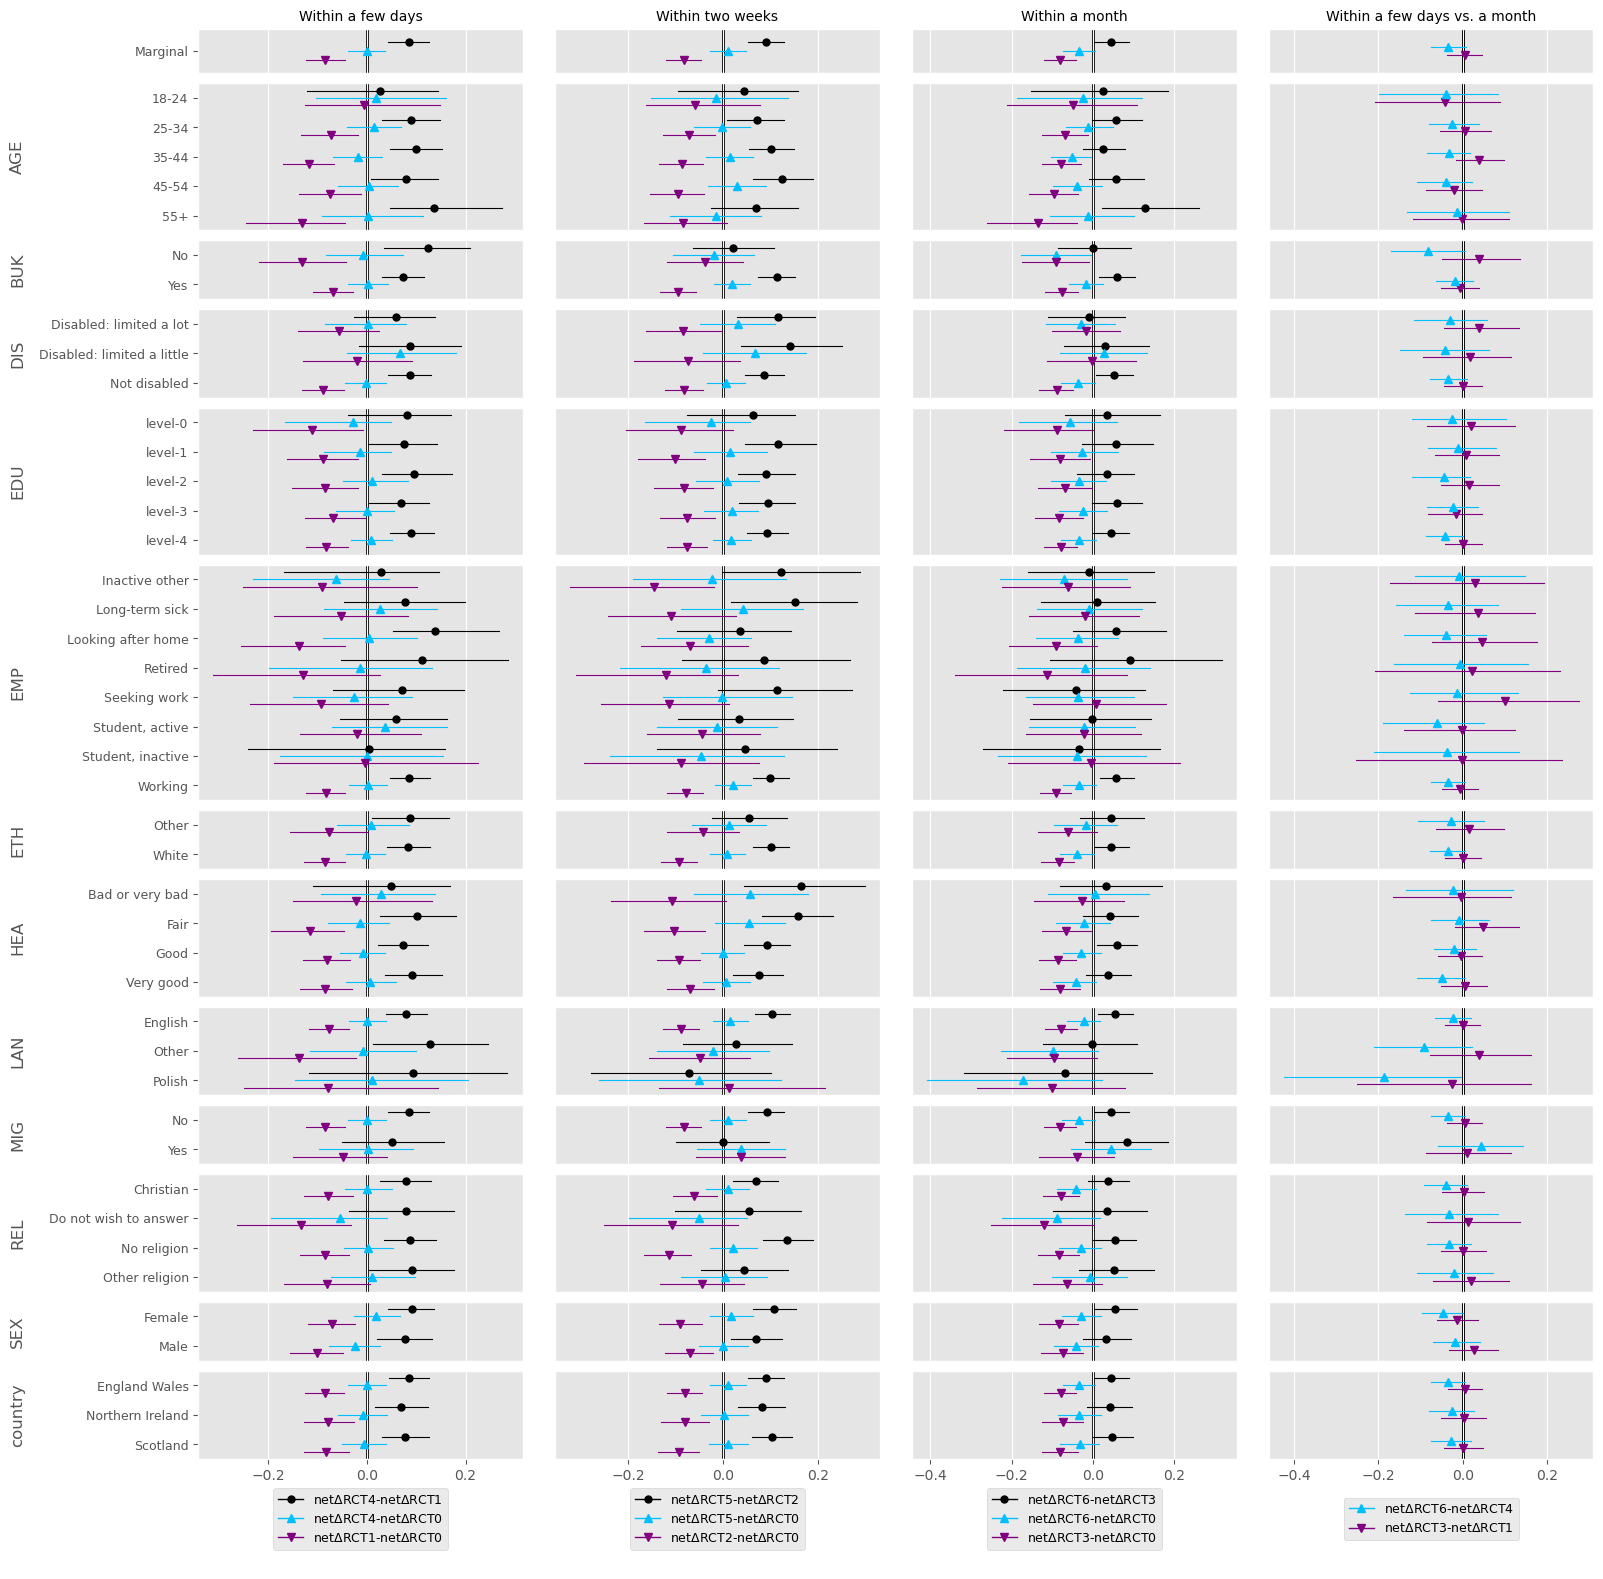

In [15]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

categories_dict = {var : list( rename_mapping_for_plot[var].values() ) for var in _var_list } # {'no_post_strat_var' : ['Marginal']}
categories_dict = {var : list( np.sort(categories) ) for var, categories in categories_dict.items() }

_ordered_cats = list(categories_dict)

_ordered_cats = ['no_post_strat_var'] + list( np.sort([k for k in _ordered_cats if k != 'no_post_strat_var']) )


categories_dict = {k:categories_dict[k] for k in _ordered_cats}

add_n = True

_y_offset = 0.5
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

height_ratios = [_get_height( len(categories), y_offset=_y_offset) for var, categories in categories_dict.items()] + [3.4]

height_ratios[0] += 0.5

plt.style.use('ggplot')

fig = plt.figure(figsize=(18, 20) ) # plt.figure(figsize=(15, 16) )  # plt.figure(figsize=(18, 20) ) # , constrained_layout = True)
gs = GridSpec(len(_var_list) + 1, 4, figure=fig, wspace=0.1, hspace=0.1, height_ratios=height_ratios)

axes = []
for i in range(len(_var_list)):
    row_axes = []
    for j in range(4):
        if i == 0:
            ax = fig.add_subplot(gs[i, j])
        else:
            ax = fig.add_subplot(gs[i, j], sharex=axes[0][j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.align_labels()
titles = ['Within a few days', 'Within two weeks', 'Within a month'] + ['Within a few days vs. a month']

# 
lower_per_list = []
upper_per_list = []
for i, (var_post_strat, categories) in enumerate( categories_dict.items() ):
    num_rows = len(categories)
    for j, treat_type in enumerate(titles[:3]):
        ax = axes[i][j]
        for k, (index, row) in enumerate( (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][j+1] ).T.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            lower_per_list.append(lower_per)
            upper_per_list.append(upper_per)
x_min, x_max = np.min(lower_per_list), np.max(upper_per_list)

#
delta1 = 0.2
delta2 = 0.25

ls_style1 = '-'
ls_style2 = '-'#(0, (3, 1, 1, 1, 1, 1)) 
ls_style3 = '-'#':'

marker_style1 = 'o'
marker_style2 = '^'
marker_style3 = 'v'

lw1, lw2, lw3 = 0.8,0.8,0.8

c1, c2, c3 = 'black', 'deepskyblue', 'purple'

for i, (var_post_strat, categories) in enumerate( categories_dict.items() ):
    num_rows = len(categories)
    if i == 0:
        delta = delta1
    else:
        delta = delta2
    for j, treat_type in enumerate(titles[:3]):
        ax = axes[i][j]

        _df_change1 = (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][j+1] ).T
        _df_change2 = (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][0] ).T
        _df_change3 = (change_dict[var_post_strat]['net_change'][j+1] - change_dict[var_post_strat]['net_change'][0] ).T
        
        if var_post_strat == 'DIS':
            dis_index = _df_change1.index
            dis_index = dis_index[[1,0,2]]
            dis_index = [label.replace('\n', ' ')for label in dis_index]
            _df_change1.index = dis_index
            _df_change2.index = dis_index
            _df_change3.index = dis_index
        
        for k, (index, row) in enumerate( _df_change1.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k + delta, num_rows - 1 - k + delta], color=c1, ls = ls_style1, lw=lw1)
            ax.plot(middle_per, num_rows - 1 - k + delta, marker_style1, color=c1, markersize = 5) 

        for k, (index, row) in enumerate( _df_change2.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k, num_rows - 1 - k], color=c2, ls = ls_style2, lw=lw2 ) # 'dashdot')
            ax.plot(middle_per, num_rows - 1 - k, marker_style2, color=c2, markersize = 5.5) 

        for k, (index, row) in enumerate( _df_change3.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k - delta, num_rows - 1 - k - delta], color=c3, ls = ls_style3, lw=lw3 )
            ax.plot(middle_per, num_rows - 1 - k - delta, marker_style3, color=c3, markersize = 5.5) 

        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            _ytick_labels =  list(_df_change1.index)[::-1]
            ax.set_yticklabels( _ytick_labels, fontsize = 9) 
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        ax.axvline(0, zorder = 0, color = 'black', lw = 2)
        if i == 0:
            ax.set_title(titles[j], size = 10)
        if i != len(_var_list) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ###########
    ax = axes[i][3]
    _df_change1 = (change_dict[var_post_strat]['net_change'][2] - change_dict[var_post_strat]['net_change'][1] ).T
    _df_change2 = (change_dict[var_post_strat]['net_change'][3] - change_dict[var_post_strat]['net_change'][1] ).T
    _df_change3 = (change_dict[var_post_strat]['net_change'][5] - change_dict[var_post_strat]['net_change'][4] ).T
    _df_change4 = (change_dict[var_post_strat]['net_change'][6] - change_dict[var_post_strat]['net_change'][4] ).T


    d1,d2,d3,d4 = 'purple','purple', 'deepskyblue', 'deepskyblue'
    m1,m2,m3,m4 = 'v','v','^','^'

    for k, (index, row) in enumerate( _df_change2.iterrows() ):
        lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k - 0.5*delta, num_rows - 1 - k - 0.5*delta], color=d2, ls = ls_style2, lw=lw2 ) # 'dashdot')
        ax.plot(middle_per, num_rows - 1 - k - 0.5*delta, m2, color=d2, markersize = 5.5) 

    for k, (index, row) in enumerate( _df_change4.iterrows() ):
        lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k + 0.5*delta, num_rows - 1 - k + 0.5*delta], color=d4, ls = ls_style3, lw=lw3 )
        ax.plot(middle_per, num_rows - 1 - k + 0.5*delta, m4, color=d4, markersize = 5.5) 
    ax.axvline(0, zorder = 0, color = 'black', lw = 2)
    ax.grid(axis='y', visible=False)

    if i == 0:
        ax.set_title(titles[-1], size = 10)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    if j == 0:
        ax.set_yticks( range( num_rows ) )
        _ytick_labels =  list(_df_change1.index)[::-1]
        ax.set_yticklabels( _ytick_labels, fontsize = 9) 
    else:
        ax.set_yticks( [] )
    ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
    ax.axvline(0, zorder = 0, color = 'black', lw = 2)
    if i != len(_var_list) - 1:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ############
    if var_post_strat != 'no_post_strat_var':    
        axes[i][0].set_ylabel(var_post_strat, labelpad=10)
    axes[i][0].grid(axis='y', visible=False)

from matplotlib.lines import Line2D

# Define custom line styles for the legend
solid_line = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT4-net$\Delta$RCT1', marker=marker_style1, markersize=5)
dashdot_line = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT4-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT1-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)

solid_line_col1 = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT5-net$\Delta$RCT2', marker=marker_style1, markersize=5)
dashdot_line_col1 = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT5-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line_col1 = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT2-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)

solid_line_col2 = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT3', marker=marker_style1, markersize=5)
dashdot_line_col2 = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line_col2 = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT3-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)

line_1 = Line2D([0], [0], color=d4, ls=ls_style1, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT4', marker=m4, markersize=5.5)
line_2 = Line2D([0], [0], color=d2, ls=ls_style1, lw=1, label=r'net$\Delta$RCT3-net$\Delta$RCT1', marker=m2, markersize=5.5)


legend_ax = fig.add_subplot(gs[-1, 0])  
legend_ax.axis('off') 
legend_ax.legend(handles=[solid_line, dashdot_line, dotted_line], loc='center', fontsize=9)

legend_ax = fig.add_subplot(gs[-1, 1]) 
legend_ax.axis('off')
legend_ax.legend(handles=[solid_line_col1, dashdot_line_col1, dotted_line_col1], loc='center', fontsize=9)

legend_ax = fig.add_subplot(gs[-1, 2])  
legend_ax.axis('off')  
legend_ax.legend(handles=[solid_line_col2, dashdot_line_col2, dotted_line_col2], loc='center', fontsize=9)

legend_ax = fig.add_subplot(gs[-1, 3])  
legend_ax.axis('off')  
legend_ax.legend(handles=[line_1, line_2], loc='center', fontsize=9)

fig.savefig('./fig/uk/rsv_intent_causal_poststrat_soc_net_change_w_time_eff.jpg', dpi = 200, bbox_inches='tight')

In [16]:
N_dep = 4
N_treat = 7

prob_joint_pre_post = np.zeros((num_samples, N_dep, N_treat, N_dep))

prob_pre_post_cond_on_pre = np.zeros((num_samples, N_dep, N_treat, N_dep))

prob_pre = np.zeros((num_samples, N_dep, N_treat))

for p1 in range(N_dep):
    for t in range(N_treat):
        _df = df_post_strat_dict['no_post_strat_var'][f'p{p1+1}'][t].copy()
        _prob_pre = np.zeros((num_samples,))
        for p2 in range(N_dep):
            cols = [f'p{p2+1}_{s}' for s in range(num_samples)]
            vals = _df[cols].values.reshape(-1)
            prob_joint_pre_post[:, p1, t, p2] = vals 
            _prob_pre += vals
        prob_pre[:,p1,t] = _prob_pre

for p1 in range(N_dep):
    for t in range(N_treat):
        for p2 in range(N_dep):
            prob_pre_post_cond_on_pre[:, p1, t, p2] = prob_joint_pre_post[:, p1, t, p2] / prob_pre[:,p1,t]

prob_post = np.zeros((num_samples, N_treat, N_dep))
for t in range(N_treat):
    for p2 in range(N_dep):
        prob_post[:,t,p2] = prob_joint_pre_post[:,:,t,p2].sum(axis = 1)

# combine low intent and high intent
prob_pre_red = np.zeros((num_samples,2,N_treat))
prob_pre_red[:,0,:] = prob_pre[:,0,:] + prob_pre[:,1,:]
prob_pre_red[:,1,:] = prob_pre[:,2,:] + prob_pre[:,3,:]

prob_pre_red_comb = prob_pre_red.transpose(0, 2, 1).reshape(num_samples*N_treat, -1)

prob_pre_comb = prob_pre.transpose(0, 2, 1).reshape(num_samples*N_treat, -1)


# combine low intent and high intent
prob_post_red = np.zeros((num_samples,N_treat,2))
prob_post_red[:,:,0] = prob_post[:,:,0] + prob_post[:,:,1]
prob_post_red[:,:,1] = prob_post[:,:,2] + prob_post[:,:,3]

Text(0.5, 1.0, 'Leaning yes or Definitely yes')

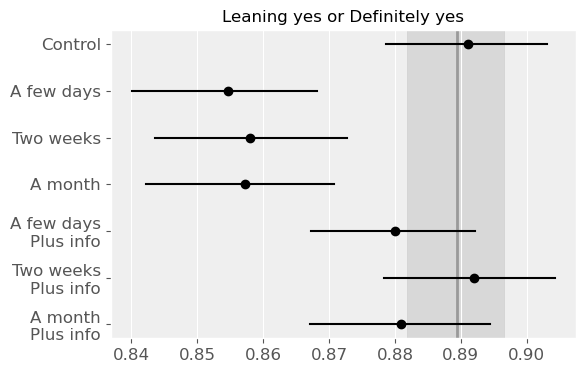

In [17]:
plt.style.use('ggplot')

rct_explanation = {0 : 'Control',1 : 'A few days', 2 : 'Two weeks', 3 : 'A month', 
              4 : 'A few days\nPlus info', 5 : 'Two weeks\nPlus info', 6 : 'A month\nPlus info'}

fig,ax = plt.subplots(figsize = (6,4))

for t in range(N_treat):
    row = N_treat-1-t
    percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_post_red[:,t,1],[2.5, 50, 97.5] )
    ax.plot([percentile_2_5, percentile_97_5], [row, row], color='black')  # Line from 2.5 to 97.5 percentile
    ax.plot( percentile_50, row, 'o', color='black')  

ax.set_yticks(range(N_treat))
ax.set_yticklabels([ rct_explanation[row] for row in reversed(range(N_treat))], fontsize = 12 )
ax.tick_params(axis='x', labelsize=12)

percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_pre_red_comb[:,1],[2.5, 50, 97.5] )
# Plot the central line for the median
ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.7, lw = 2)

ax.axvspan(percentile_2_5,
           percentile_97_5,
           ymin=0, ymax=1,           # full axis in y
           color='grey',
           alpha=0.2,
           zorder=0)
########################
ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

ax.grid(axis='y', visible=False)

ax.set_title('Leaning yes or Definitely yes', size = 12)

fig.savefig('./fig/uk/rsv_intent_causal_poststrat_probs_leaning_yes_definitely_yes.jpg', dpi = 200, bbox_inches='tight')

Text(0.5, 1.0, 'Definitely yes')

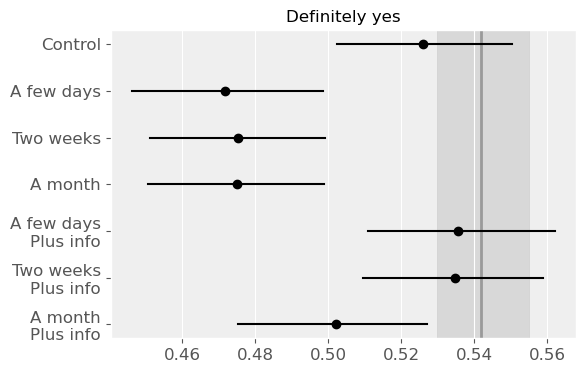

In [18]:
plt.style.use('ggplot')

rct_explanation = {0 : 'Control',1 : 'A few days', 2 : 'Two weeks', 3 : 'A month', 
              4 : 'A few days\nPlus info', 5 : 'Two weeks\nPlus info', 6 : 'A month\nPlus info'}

fig,ax = plt.subplots(figsize = (6,4))

for t in range(N_treat):
    row = N_treat-1-t
    percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_post[:,t,3],[2.5, 50, 97.5] )
    ax.plot([percentile_2_5, percentile_97_5], [row, row], color='black')  # Line from 2.5 to 97.5 percentile
    ax.plot( percentile_50, row, 'o', color='black')  

ax.set_yticks(range(N_treat))
ax.set_yticklabels([ rct_explanation[row] for row in reversed(range(N_treat))], fontsize = 12 )
ax.tick_params(axis='x', labelsize=12)

percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_pre_comb[:,3],[2.5, 50, 97.5] )
# Plot the central line for the median
ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.7, lw = 2)

ax.axvspan(percentile_2_5,
           percentile_97_5,
           ymin=0, ymax=1,           # full axis in y
           color='grey',
           alpha=0.2,
           zorder=0)
########################
ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

ax.grid(axis='y', visible=False)

ax.set_title('Definitely yes', size = 12)

fig.savefig('./fig/uk/rsv_intent_causal_poststrat_probs_definitely_yes.jpg', dpi = 200, bbox_inches='tight')

Text(0.5, 1.0, 'Leaning yes')

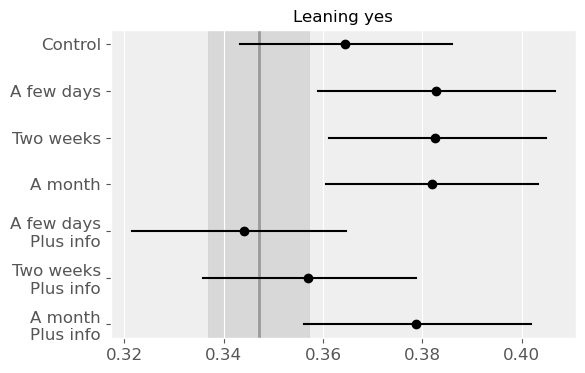

In [19]:
plt.style.use('ggplot')

rct_explanation = {0 : 'Control',1 : 'A few days', 2 : 'Two weeks', 3 : 'A month', 
              4 : 'A few days\nPlus info', 5 : 'Two weeks\nPlus info', 6 : 'A month\nPlus info'}

fig,ax = plt.subplots(figsize = (6,4))

for t in range(N_treat):
    row = N_treat-1-t
    percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_post[:,t,2],[2.5, 50, 97.5] )
    ax.plot([percentile_2_5, percentile_97_5], [row, row], color='black')  # Line from 2.5 to 97.5 percentile
    ax.plot( percentile_50, row, 'o', color='black')  

ax.set_yticks(range(N_treat))
ax.set_yticklabels([ rct_explanation[row] for row in reversed(range(N_treat))], fontsize = 12 )
ax.tick_params(axis='x', labelsize=12)

percentile_2_5, percentile_50, percentile_97_5 = np.percentile(prob_pre_comb[:,2],[2.5, 50, 97.5] )
# Plot the central line for the median
ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.7, lw = 2)

ax.axvspan(percentile_2_5,
           percentile_97_5,
           ymin=0, ymax=1,           # full axis in y
           color='grey',
           alpha=0.2,
           zorder=0)
########################
ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

ax.grid(axis='y', visible=False)

ax.set_title('Leaning yes', size = 12)

In [20]:
_data = {
    '2.5 per.': [],
    'median': [],
    '97.5 per.': [],
    'mean': []
}


p2_5, p50, p97_5 = np.percentile(prob_pre_red_comb[:,1],[2.5, 50, 97.5] )
_data['2.5 per.'].append(p2_5)
_data['median'].append(p50)
_data['97.5 per.'].append(p97_5)
_data['mean'].append(prob_pre_red_comb[:,1].mean())

for t in rct_explanation:
    samples = prob_post_red[:, t, 1]
    p2_5, p50, p97_5 = np.percentile(samples, [2.5, 50, 97.5])
    _data['2.5 per.'].append(p2_5)
    _data['median'].append(p50)
    _data['97.5 per.'].append(p97_5)
    _data['mean'].append(samples.mean())

df_yes = pd.DataFrame(_data, index= ['Pre-intent'] + list( rct_explanation.values()) )

df_yes_latex = df_yes.to_latex(index=True, escape=True)

with open("./tables/rsv_intent_causal_poststrat_probs_leaning_yes_definitely_yes_table.tex", "w") as file:
    file.write(df_yes_latex)

df_yes

,2.5 per.,median,97.5 per.,mean
Pre-intent,0.881798,0.889365,0.896487,0.889367
Control,0.878692,0.891067,0.903115,0.891120
A few days,0.840110,0.854663,0.868164,0.854653
Two weeks,0.843690,0.858037,0.872680,0.858056
A month,0.842273,0.857201,0.870697,0.856829
A few days\nPlus info,0.867310,0.880055,0.892110,0.879960
Two weeks\nPlus info,0.878382,0.892056,0.904202,0.891744
A month\nPlus info,0.867135,0.880958,0.894437,0.880822


In [21]:
_data = {
    '2.5 per.': [],
    'median': [],
    '97.5 per.': [],
    'mean': []
}


p2_5, p50, p97_5 = np.percentile(prob_pre_comb[:,3],[2.5, 50, 97.5] )
_data['2.5 per.'].append(p2_5)
_data['median'].append(p50)
_data['97.5 per.'].append(p97_5)
_data['mean'].append(prob_pre_red_comb[:,1].mean())

for t in rct_explanation:
    samples = prob_post[:, t, 3]
    p2_5, p50, p97_5 = np.percentile(samples, [2.5, 50, 97.5])
    _data['2.5 per.'].append(p2_5)
    _data['median'].append(p50)
    _data['97.5 per.'].append(p97_5)
    _data['mean'].append(samples.mean())

df_def_yes = pd.DataFrame(_data, index= ['Pre-intent'] + list( rct_explanation.values()) )

df_def_yes_latex = df_def_yes.to_latex(index=True, escape=True)

with open("./tables/rsv_intent_causal_poststrat_probs_definitely_yes_table.tex", "w") as file:
    file.write(df_def_yes_latex)

df_def_yes

,2.5 per.,median,97.5 per.,mean
Pre-intent,0.529908,0.541998,0.555072,0.889367
Control,0.502424,0.526099,0.550367,0.526386
A few days,0.446235,0.471831,0.498565,0.471980
Two weeks,0.451311,0.475403,0.499149,0.475449
A month,0.450694,0.474977,0.498881,0.474907
A few days\nPlus info,0.511004,0.535685,0.562049,0.535960
Two weeks\nPlus info,0.509505,0.534866,0.558826,0.534608
A month\nPlus info,0.475351,0.502097,0.527121,0.501969


In [22]:
rct_explanation = {0 : 'Control',1 : 'A few days', 2 : 'Two weeks', 3 : 'A month', 
              4 : 'A few days\nPlus info', 5 : 'Two weeks\nPlus info', 6 : 'A month\nPlus info'}

palette = {
    3: sns.color_palette("Blues", n_colors=8)[6],  # High Positive (Dark Blue)
    2: sns.color_palette("Blues", n_colors=8)[4],  # Medium Positive (Medium Blue)
    1: sns.color_palette("Blues", n_colors=8)[2],  # Low Positive (Light Blue)
    0 : sns.color_palette("Grays", n_colors=7)[2],
    -1: sns.color_palette("Reds", n_colors=8)[2],  # Low Negative (Light Red)
    -2: sns.color_palette("Reds", n_colors=8)[4],  # Medium Negative
    -3: sns.color_palette("Reds", n_colors=8)[6],  # High Negative (Dark Red)
}

legend_labels = {        
            3: '99.5% of posterior of poststratified difference in probabilities above 0',
            2: '95% of posterior of poststratified difference in probabilities above 0',
            1: '90% of posterior of poststratified difference in probabilities above 0',
            0: 'At least 10% of posterior of poststratified difference in probabilities below and 10% above 0',
            -1: '90% of posterior of poststratified difference in probabilities below 0',
            -2: '95% of posterior of poststratified difference in probabilities below 0',
            -3: '99.5% of posterior of poststratified difference in probabilities below 0',}

In [24]:
def get_color(df,c):
    perc = 0.1 * 50
    if ( np.percentile(df[c], 10) > 0 ) and (np.percentile(df[c], 5) <= 0):
        return(palette[1])
    # elif ( np.percentile(df[c], 5) > 0 ) and (np.percentile(df[c], 2.5) <= 0):
    elif ( np.percentile(df[c], 5) > 0 ) and (np.percentile(df[c], 0.5) <= 0):
        return(palette[2])
        
    # elif (np.percentile(df[c], 2.5) > 0):
    elif (np.percentile(df[c], 0.5) > 0):
        # return('deepskyblue')
        return(palette[3])
        
    elif (np.percentile(df[c], 90) < 0) and (np.percentile(df[c], 95) >= 0):
        return(palette[-1])
    
    # elif (np.percentile(df[c], 95) < 0) and (np.percentile(df[c], 97.5) >= 0):
    elif (np.percentile(df[c], 95) < 0) and (np.percentile(df[c], 99.5) >= 0):
        return(palette[-2])
    # elif (np.percentile(df[c], 97.5) < 0):
    elif (np.percentile(df[c], 99.5) < 0):
        return(palette[-3])
    else:
        return(palette[0])

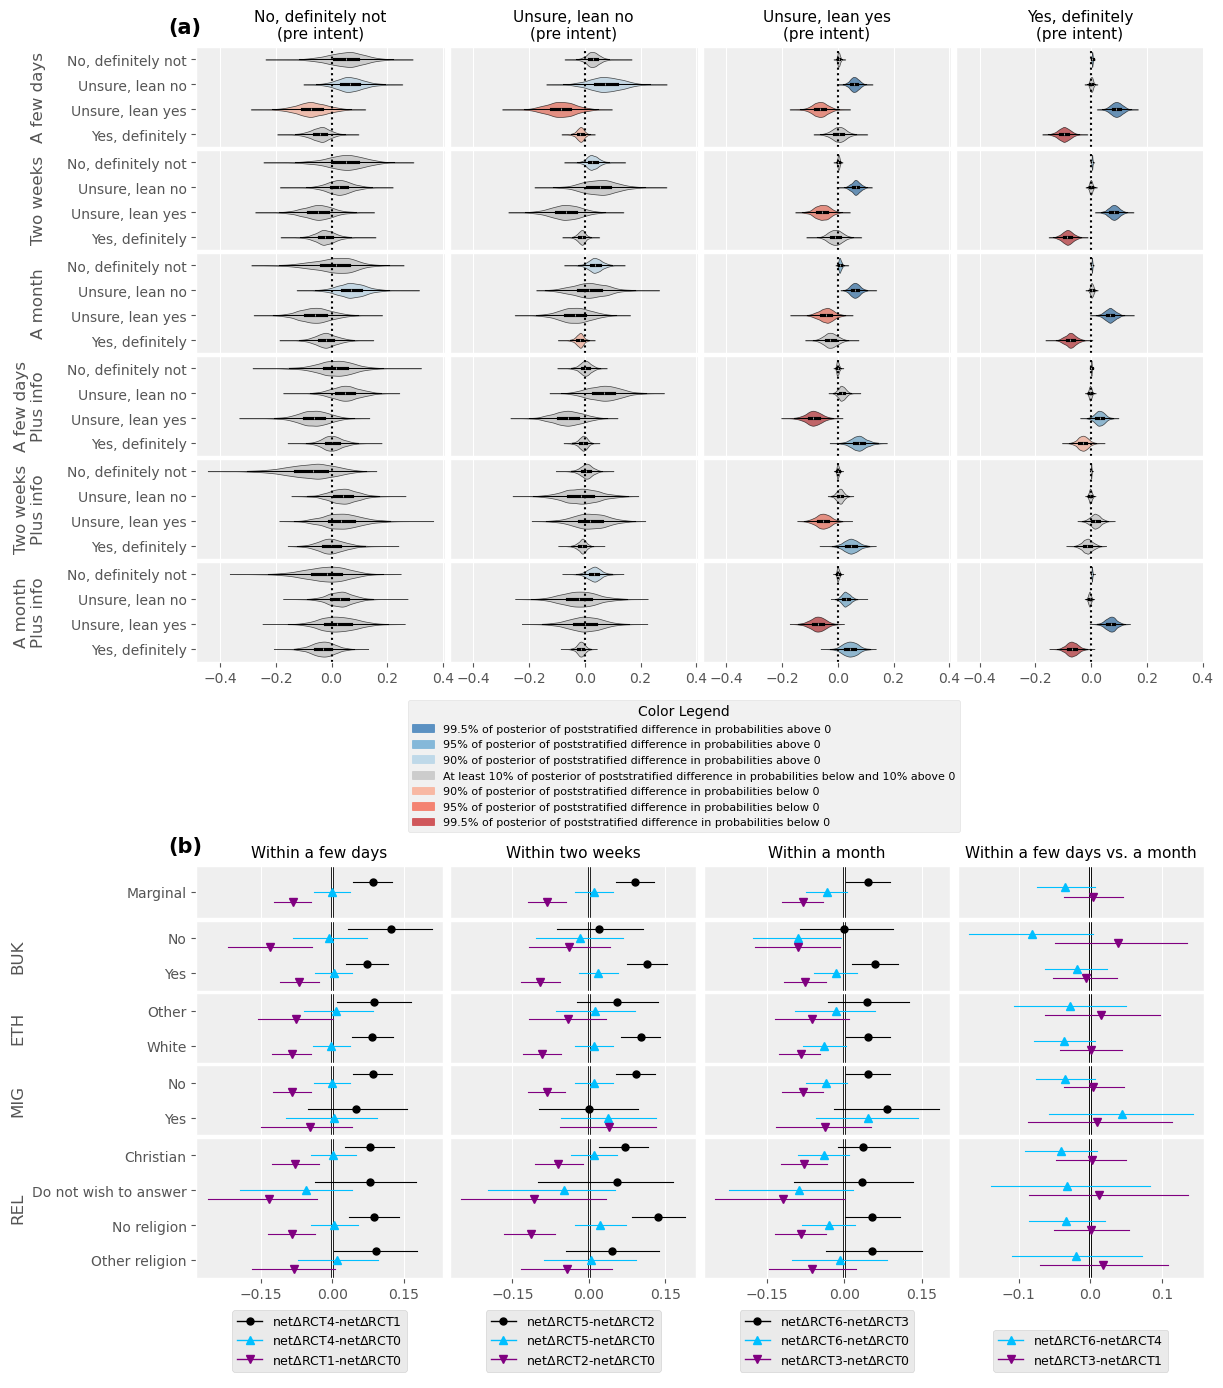

In [25]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

labelpad1 = 15
labelpad2 = 5

categories_dict = {var : list( rename_mapping_for_plot[var].values() ) for var in _var_list } # {'no_post_strat_var' : ['Marginal']}
categories_dict = {var : list( np.sort(categories) ) for var, categories in categories_dict.items() }


categories_dict = {k:categories_dict[k] for k in ['no_post_strat_var','BUK','ETH','MIG','REL']}

add_n = True

_y_offset = 0.5
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

height_ratios = [_get_height( len(categories), y_offset=_y_offset) for var, categories in categories_dict.items()] + [2.8]

height_ratios[0] += 0.5

plt.style.use('ggplot')

fig = plt.figure(figsize=(13, 15)) # fig = plt.figure(layout='constrained', figsize=(13, 15))

subfigs = fig.subfigures(2, 1, wspace=0.07, hspace = 0.05, height_ratios=[1.2, 1])
subfig0 = subfigs[1]
subfig1 = subfigs[0]


gs = GridSpec(len(categories_dict) + 1, 4, figure=subfig0, wspace=0.03, hspace=0.03, height_ratios=height_ratios)


axes = []
for i in range(len(categories_dict)):
    row_axes = []
    for j in range(4):
        if i == 0:
            ax = subfig0.add_subplot(gs[i, j])
        else:
            ax = subfig0.add_subplot(gs[i, j], sharex=axes[0][j])
        row_axes.append(ax)
    axes.append(row_axes)

subfig0.align_labels()
titles = ['Within a few days', 'Within two weeks', 'Within a month'] + ['Within a few days vs. a month']
title_size = 11
# 
lower_per_list = []
upper_per_list = []
for i, (var_post_strat, categories) in enumerate( categories_dict.items() ):
    num_rows = len(categories)
    for j, treat_type in enumerate(titles[:3]):
        ax = axes[i][j]
        for k, (index, row) in enumerate( (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][j+1] ).T.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            lower_per_list.append(lower_per)
            upper_per_list.append(upper_per)
x_min, x_max = np.min(lower_per_list), np.max(upper_per_list)

#
delta1 = 0.2
delta2 = 0.25

ls_style1 = '-'
ls_style2 = '-'#(0, (3, 1, 1, 1, 1, 1)) 
ls_style3 = '-'#':'

marker_style1 = 'o'
marker_style2 = '^'
marker_style3 = 'v'

lw1, lw2, lw3 = 0.8,0.8,0.8

c1, c2, c3 = 'black', 'deepskyblue', 'purple'

for i, (var_post_strat, categories) in enumerate( categories_dict.items() ):
    num_rows = len(categories)
    if i == 0:
        delta = delta1
    else:
        delta = delta2
    for j, treat_type in enumerate(titles[:3]):
        ax = axes[i][j]

        _df_change1 = (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][j+1] ).T
        _df_change2 = (change_dict[var_post_strat]['net_change'][j+1+3] - change_dict[var_post_strat]['net_change'][0] ).T
        _df_change3 = (change_dict[var_post_strat]['net_change'][j+1] - change_dict[var_post_strat]['net_change'][0] ).T
        
        if var_post_strat == 'DIS':
            dis_index = _df_change1.index
            dis_index = dis_index[[1,0,2]]
            dis_index = [label.replace('\n', ' ')for label in dis_index]
            _df_change1.index = dis_index
            _df_change2.index = dis_index
            _df_change3.index = dis_index
        
        for k, (index, row) in enumerate( _df_change1.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k + delta, num_rows - 1 - k + delta], color=c1, ls = ls_style1, lw=lw1)
            ax.plot(middle_per, num_rows - 1 - k + delta, marker_style1, color=c1, markersize = 5) 

        for k, (index, row) in enumerate( _df_change2.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k, num_rows - 1 - k], color=c2, ls = ls_style2, lw=lw2 ) # 'dashdot')
            ax.plot(middle_per, num_rows - 1 - k, marker_style2, color=c2, markersize = 5.5) 

        for k, (index, row) in enumerate( _df_change3.iterrows() ):
            lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
            ax.plot( [lower_per, upper_per], [num_rows - 1 - k - delta, num_rows - 1 - k - delta], color=c3, ls = ls_style3, lw=lw3 )
            ax.plot(middle_per, num_rows - 1 - k - delta, marker_style3, color=c3, markersize = 5.5) 
  
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            _ytick_labels =  list(_df_change1.index)[::-1]
            ax.set_yticklabels( _ytick_labels) #, fontsize = 9) 
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        ax.axvline(0, zorder = 0, color = 'black', lw = 2)

        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
        if i == 0:
            ax.set_title(titles[j], size = title_size)
        if i != len(categories_dict) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ###########
    ax = axes[i][3]
    _df_change1 = (change_dict[var_post_strat]['net_change'][2] - change_dict[var_post_strat]['net_change'][1] ).T
    _df_change2 = (change_dict[var_post_strat]['net_change'][3] - change_dict[var_post_strat]['net_change'][1] ).T
    _df_change3 = (change_dict[var_post_strat]['net_change'][5] - change_dict[var_post_strat]['net_change'][4] ).T
    _df_change4 = (change_dict[var_post_strat]['net_change'][6] - change_dict[var_post_strat]['net_change'][4] ).T


    d1,d2,d3,d4 = 'purple','purple', 'deepskyblue', 'deepskyblue'
    m1,m2,m3,m4 = 'v','v','^','^'

    for k, (index, row) in enumerate( _df_change2.iterrows() ):
        lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k - 0.5*delta, num_rows - 1 - k - 0.5*delta], color=d2, ls = ls_style2, lw=lw2 ) # 'dashdot')
        ax.plot(middle_per, num_rows - 1 - k - 0.5*delta, m2, color=d2, markersize = 5.5) 

    for k, (index, row) in enumerate( _df_change4.iterrows() ):
        lower_per, middle_per, upper_per = np.percentile(row, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k + 0.5*delta, num_rows - 1 - k + 0.5*delta], color=d4, ls = ls_style3, lw=lw3 )
        ax.plot(middle_per, num_rows - 1 - k + 0.5*delta, m4, color=d4, markersize = 5.5) 
    ax.axvline(0, zorder = 0, color = 'black', lw = 2)
    ax.grid(axis='y', visible=False)

    if i == 0:
        ax.set_title(titles[-1], size = title_size)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    if j == 0:
        ax.set_yticks( range( num_rows ) )
        _ytick_labels =  list(_df_change1.index)[::-1]
        ax.set_yticklabels( _ytick_labels) #, fontsize = 9) 
    else:
        ax.set_yticks( [] )
    ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
    ax.axvline(0, zorder = 0, color = 'black', lw = 2)
    if i != len(categories_dict) - 1:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    ############
    if var_post_strat != 'no_post_strat_var':    
        axes[i][0].set_ylabel(var_post_strat, labelpad=labelpad2)
    axes[i][0].grid(axis='y', visible=False)
    
ax = axes[0][0]
ax.text(
    0.0, 1.0, '(b)', transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=15, va='bottom', fontweight='bold') #, fontfamily='serif'
from matplotlib.lines import Line2D

# Define custom line styles for the legend
solid_line = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT4-net$\Delta$RCT1', marker=marker_style1, markersize=5)
dashdot_line = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT4-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT1-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)

solid_line_col1 = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT5-net$\Delta$RCT2', marker=marker_style1, markersize=5)
dashdot_line_col1 = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT5-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line_col1 = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT2-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)

solid_line_col2 = Line2D([0], [0], color=c1, ls=ls_style1, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT3', marker=marker_style1, markersize=5)
dashdot_line_col2 = Line2D([0], [0], color=c2, ls=ls_style2, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT0', marker=marker_style2, markersize=5.5)
dotted_line_col2 = Line2D([0], [0], color=c3, ls=ls_style3, lw=1, label=r'net$\Delta$RCT3-net$\Delta$RCT0', marker=marker_style3, markersize=5.5)


line_1 = Line2D([0], [0], color=d4, ls=ls_style1, lw=1, label=r'net$\Delta$RCT6-net$\Delta$RCT4', marker=m4, markersize=5.5)
line_2 = Line2D([0], [0], color=d2, ls=ls_style1, lw=1, label=r'net$\Delta$RCT3-net$\Delta$RCT1', marker=m2, markersize=5.5)

legend_ax = subfig0.add_subplot(gs[-1, 0])
legend_ax.axis('off')  # Turn off the axes
legend_ax.legend(handles=[solid_line, dashdot_line, dotted_line], loc='lower center', fontsize=9)
legend_ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )


legend_ax = subfig0.add_subplot(gs[-1, 1])
legend_ax.axis('off')  # Turn off the axes
legend_ax.legend(handles=[solid_line_col1, dashdot_line_col1, dotted_line_col1], loc='lower center', fontsize=9)
legend_ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

legend_ax = subfig0.add_subplot(gs[-1, 2])
legend_ax.axis('off')  # Turn off the axes
legend_ax.legend(handles=[solid_line_col2, dashdot_line_col2, dotted_line_col2], loc='lower center', fontsize=9)
legend_ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

legend_ax = subfig0.add_subplot(gs[-1, 3])
legend_ax.axis('off')  # Turn off the axes
legend_ax.legend(handles=[line_1, line_2], loc='lower center', fontsize=9)
legend_ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

################################

recode_rct_for_plot = {0 : 'No, definitely not', 1 :'Unsure, lean no', 2:'Unsure, lean yes', 3 : 'Yes, definitely'}

control = 0

axes = subfig1.subplots( N_treat - 1, N_dep,sharex = True)

treatments = [t for t in range(N_treat) if t != control]

for j,t in enumerate(treatments):
    for y_pre in range(N_dep):
        ax = axes[j, y_pre]
        df = pd.DataFrame( prob_pre_post_cond_on_pre[:,y_pre, t, :] - prob_pre_post_cond_on_pre[:,y_pre, control, :], columns = recode_rct_for_plot.values() )

        my_pal = {c : get_color(df,c) for c in df.columns}
        
        sns.violinplot(data = df, orient="h", ax = ax, linewidth=0.5, linecolor='black', inner= 'box', density_norm='area',
                       palette=my_pal, width=0.6, alpha = alpha_violin_plot_soc)#, color = 'magenta') #width=0.5)#, color = 'purple')#, ax=ax, palette=my_pal, linewidth=0.5, linecolor='black', inner= 'box', density_norm='area', width=violin_width)
        if y_pre == 0:
            _label = rct_explanation[t]
            ax.set_ylabel(f'{_label}', labelpad=labelpad1)
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', which='both', length=0) 
        if j == 0:
            ax.set_title(f'{list(recode_rct_for_plot.values())[y_pre]}\n(pre intent)', size = title_size)
        if j < len(treatments) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.axvline(0,ls = ':', c = 'black')

        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

ax = axes[0][0]
ax.text(
    0.0, 1.0, '(a)', transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=15, va='bottom', fontweight='bold') #, fontfamily='serif'


plt.subplots_adjust(wspace=0.02, hspace = 0.03)  

add_custom_legend(subfig1, anchor_x = 0.5, anchor_y = -0.12, framealpha = 0.5, fontsize=8, title_fontsize=10, #palette = palette,
                  alpha = alpha_violin_plot_soc, labels = legend_labels )

fig.savefig('./fig/uk/rsv_intent_causal_poststrat_probs_net_change_buk_eth_mig_rel.jpg', dpi = 200, bbox_inches='tight')

In [26]:
title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',}

baselines = {'AGE': '35-44', # '18-24',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White',
 'LAN': 'English',
 'MIG': 'No',
 'BUK': 'Yes',
 'ENP': 'Very well or well',
 'DIS' : 'Not disabled',
 'HEA': 'Good', #'Fair',
 'EMP': 'Working',
 'SCH': 'No',
}


plt.style.use('ggplot')
orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad or very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

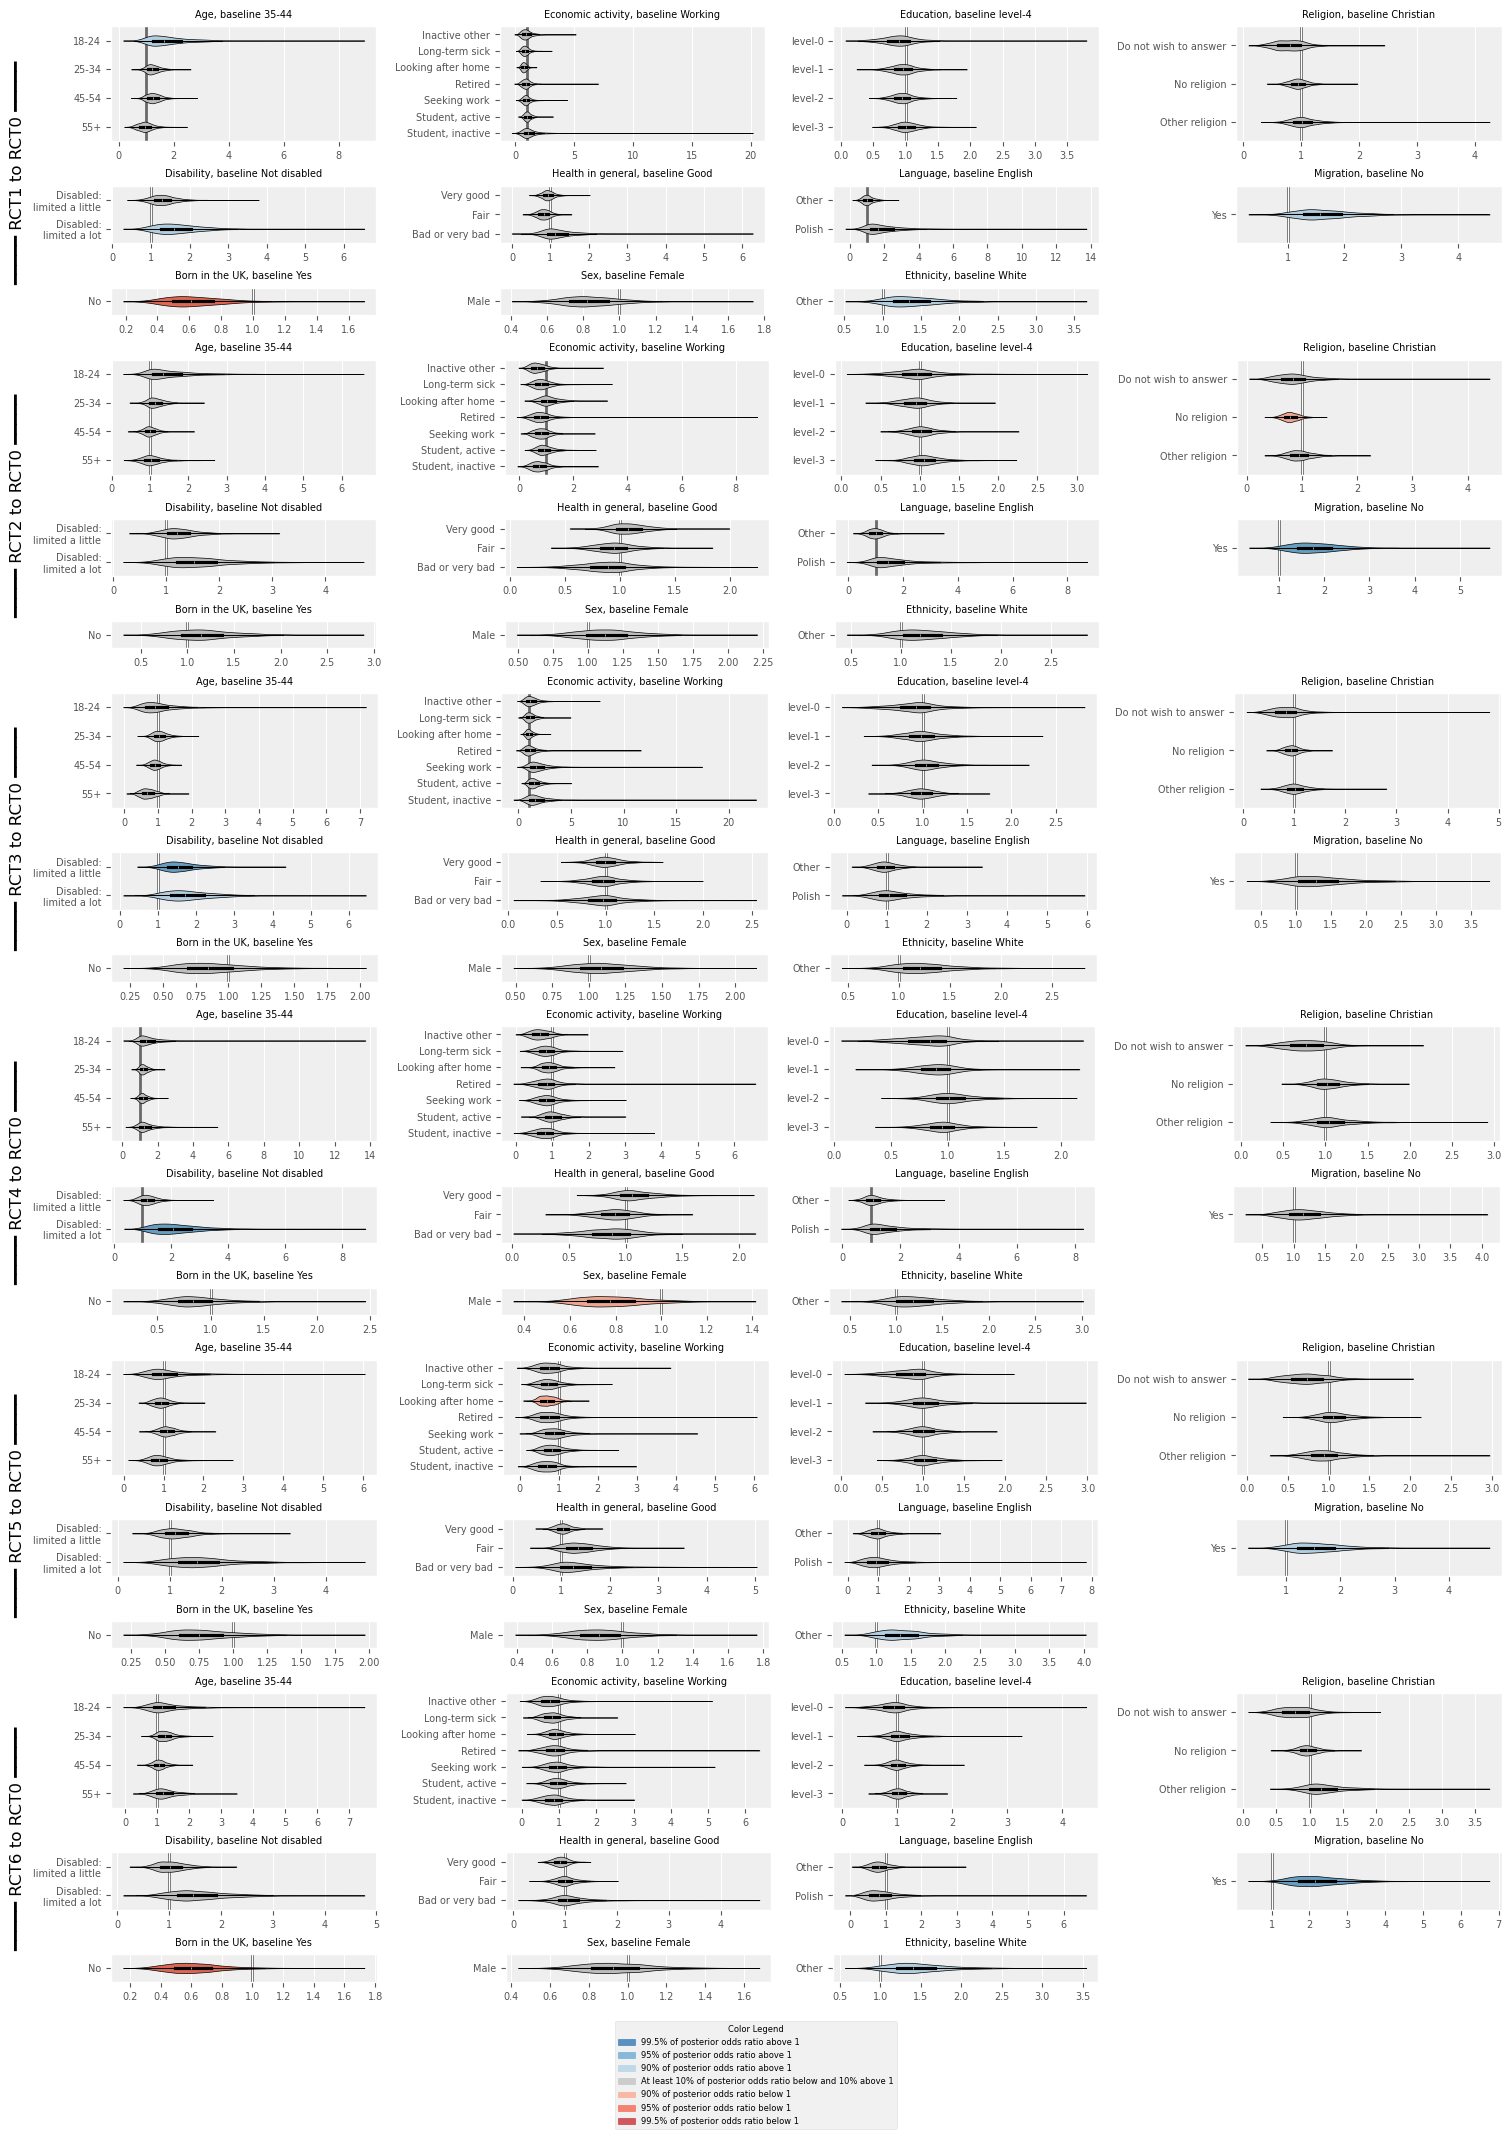

In [27]:
fig = plt.figure(layout='constrained', figsize=(15, 20))
subfigs = fig.subfigures(6, 1, wspace=0.07, hspace = 0.0)
height_ratios = [5, 2.5, 1.2]


for t in range(1,7):
    subfig = subfigs[t - 1]
    gs = GridSpec(3, 4, height_ratios=height_ratios, figure=subfig, wspace=0.05, hspace=-0.2)
    axes = [[subfig.add_subplot(gs[i, j]) for j in range(4)] for i in range(3)]
    
    for k, (var_name, coef_name) in enumerate( zip(['AGE','EMP', 'EDU','REL','DIS','HEA','LAN','MIG','BUK','SEX','ETH'], #, 'SCH'],
                                                  ['beta_age', 'beta_emp', 'beta_edu', 'beta_rel', 'beta_dis', 'beta_hea', 'beta_lan', 'beta_mig', 'beta_buk', 'beta_sex', 'beta_eth']) #, 'beta_sch'])
                                             ):
        i,j = k //4, k%4
        ax = axes[i][j]
        h_ratio = height_ratios[i]
        num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
        _title = f'{title_var_names[var_name]}, baseline {baselines[var_name]}'
        plot_odds_ratio_rct(idata = idata, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title = _title, num_samples = 2000, 
                            N_treat = 7, control = 0, treatment = t, title_size = 7,
                            plot_type = 'violin', violin_width = 0.45*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], odds_ratio = True,
                            survey = survey, add_n = False,  #palette = palette,
                            alpha = alpha_violin_plot_soc, orderd_labels_dict = orderd_labels_dict )
    
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    axes[2][3].remove()
    subfigs[t-1].supylabel(f'\u2501\u2501\u2501\u2501\u2501 RCT{t} to RCT0 \u2501\u2501\u2501\u2501\u2501', size = 12)
    if t == 6:
        add_custom_legend(subfigs[t-1], anchor_x = 0.5, anchor_y = -0.4, framealpha = 0.5, fontsize=6, title_fontsize=6, # palette = palette,
                      alpha = alpha_violin_plot_soc )

fig.savefig('./fig/uk/rsv_intent_causal_ratio_of_odds_ratios_control0_treat1-6.jpg', dpi = 200, bbox_inches='tight')